# 1. Loading the Dataset

Loaded the Tesla deliveries CSV into a DataFrame. It has 2640 rows and 12 columns. Used .info() and .describe() to get a quick look at the data types and basic stats before going further.

In [40]:
import pandas as pd

In [41]:
df = pd.read_csv(r"C:\Users\satya\satyam-python\Celebal\tesla_deliveries_dataset_2015_2025.csv")

In [42]:
print("Shape of the dataset:")
print(df.shape)

Shape of the dataset:
(2640, 12)


In [43]:
print("Columns:")
print(df.columns)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [44]:
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


In [45]:
print("Dataset Describe:")
print(df.describe())

Dataset Describe:
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min   

# 2. Missing Values and Duplicates

Checked for nulls and duplicate rows. The dataset is clean — no missing values in any column and no duplicate rows. So no cleaning needed here.

In [46]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [47]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


# 3. Exploratory Data Analysis (EDA)

Made 5 charts to understand the data better: total deliveries by Model, total deliveries by Region, a correlation heatmap, Production vs Deliveries scatter plot, and a yearly trend line. The scatter plot already hints that Production_Units and deliveries are closely related.

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

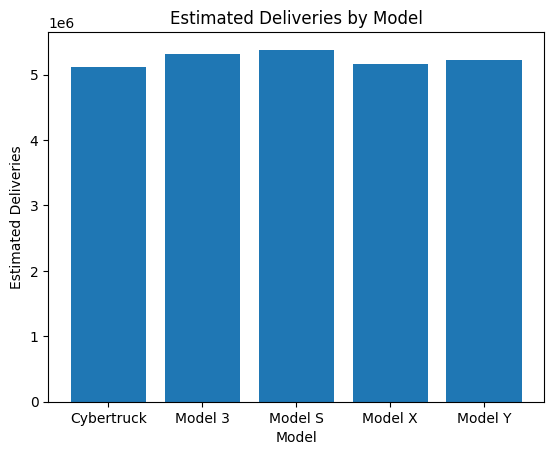

In [49]:
model = df.groupby("Model")["Estimated_Deliveries"].sum()
plt.figure()
plt.bar(model.index, model.values)

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.show()

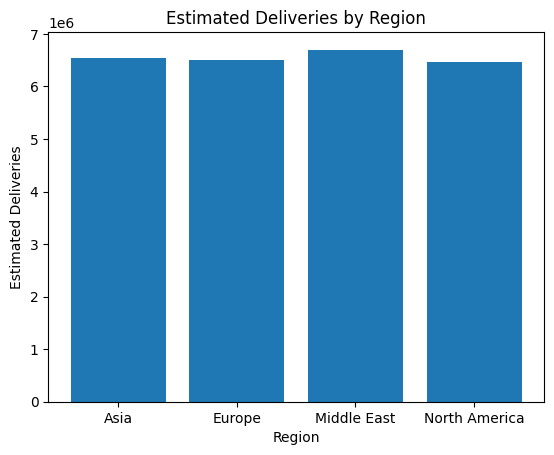

In [50]:
region = df.groupby("Region")["Estimated_Deliveries"].sum()
plt.figure()
plt.bar(region.index, region.values)

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")
plt.show()

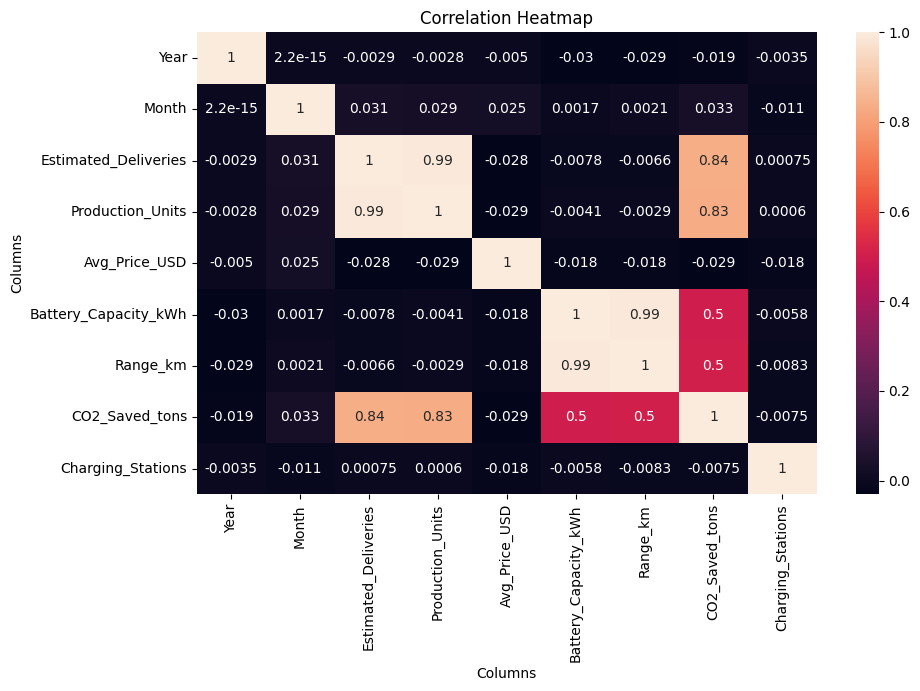

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.xlabel("Columns")
plt.ylabel("Columns")
plt.show()

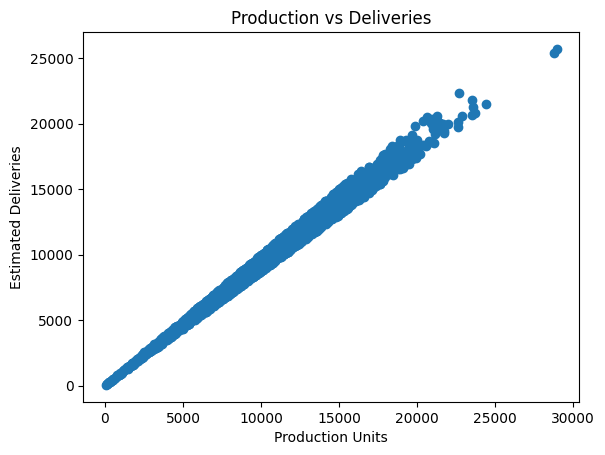

In [52]:
plt.figure()
plt.scatter(df["Production_Units"], df["Estimated_Deliveries"])
plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

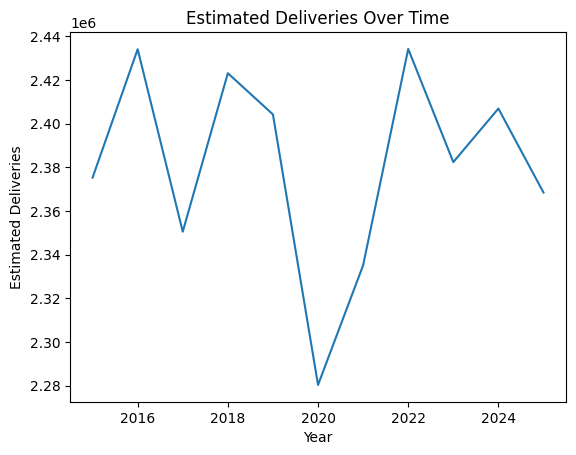

In [53]:
year = df.groupby("Year")["Estimated_Deliveries"].sum()
plt.figure()
plt.plot(year.index, year)
plt.title("Estimated Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.show()

# 4. Encoding and Feature Engineering

Encoded Region, Model, and Source_Type using LabelEncoder since they're categorical. Also added two new features — Deliveries_Lag1 (previous period's deliveries) and Rolling_Mean_3 (3-period rolling average) — to give the model some sense of past trend. Filled the first few NaN values these create with the column mean.

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Region"] = le.fit_transform(df["Region"])
df["Model"] = le.fit_transform(df["Model"])
df["Source_Type"] = le.fit_transform(df["Source_Type"])

In [55]:
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)
df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean())

In [56]:
df["Rolling_Mean_3"] = df["Estimated_Deliveries"].rolling(3).mean()
df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean())

In [57]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,9924.959454,9923.677407
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,17646.000000,9923.677407
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,3797.000000,9951.333333
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,8411.000000,6254.333333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,6555.000000,9113.333333


# 5. Linear Regression 

Split the data 80/20 by index instead of train_test_split, since this is time-based data and shuffling wouldn't make sense. Trained a Linear Regression model on the first 80% and tested on the last 20%. R² came out above 0.99, so the model fits really well — likely because Production_Units is almost the same as deliveries.

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [59]:
X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]

MAE: 310.33452153988355
RMSE: 375.56466645344744
R2 Score: 0.9908058721380986


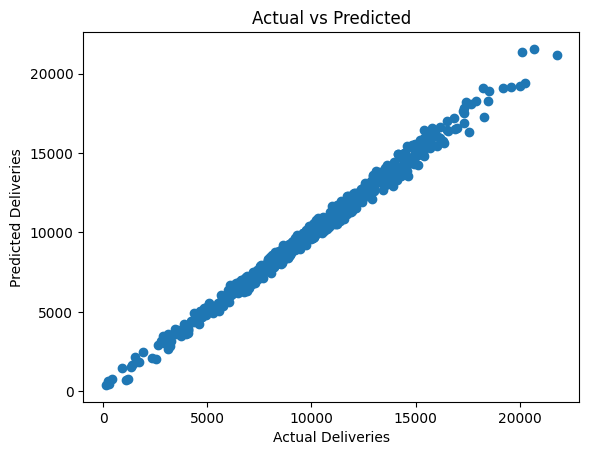

In [60]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))


plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.title("Actual vs Predicted")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.show()

# 6. Cross Validation

Ran 5-fold cross validation on the Linear Regression model to check how stable it is across different splits of the training data. All 5 folds came out around 0.99 with very low standard deviation, so the model isn't overfitting to one particular split.

In [61]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")

print("Fold 1:", scores[0])
print("Fold 2:", scores[1])
print("Fold 3:", scores[2])
print("Fold 4:", scores[3])
print("Fold 5:", scores[4])

print("Mean R2:", scores.mean())
print("Standard Deviation:", scores.std())

Fold 1: 0.9908095586481536
Fold 2: 0.9900758495238967
Fold 3: 0.9904738167254892
Fold 4: 0.9890351718572716
Fold 5: 0.9908591971077279
Mean R2: 0.9902507187725078
Standard Deviation: 0.0006693958686634371


# 7. Random Forest with GridSearchCV

Tuned a Random Forest using GridSearchCV over a few values of n_estimators and max_depth. Picked the best combination and evaluated it on the test set, then plotted feature importances. Production_Units dominates the importance scores by a wide margin, which lines up with the high correlation seen in the heatmap.

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [63]:
rf = RandomForestRegressor(random_state=42)
params = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(rf, params, cv=5, scoring="r2")
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 50}


In [64]:
best_model = grid.best_estimator_
y_pred_rf = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 303.85833333333335
RMSE: 388.5512760612014
R2 Score: 0.99015903323468


In [65]:
importance = best_model.feature_importances_
feature = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})
final = feature.sort_values(by="Importance", ascending=False)
final

,Feature,Importance
4,Production_Units,0.990055
8,CO2_Saved_tons,0.002163
7,Range_km,0.001221
5,Avg_Price_USD,0.001040
10,Charging_Stations,0.001004
12,Rolling_Mean_3,0.000955
11,Deliveries_Lag1,0.000923
0,Year,0.000888
1,Month,0.000668
3,Model,0.000357


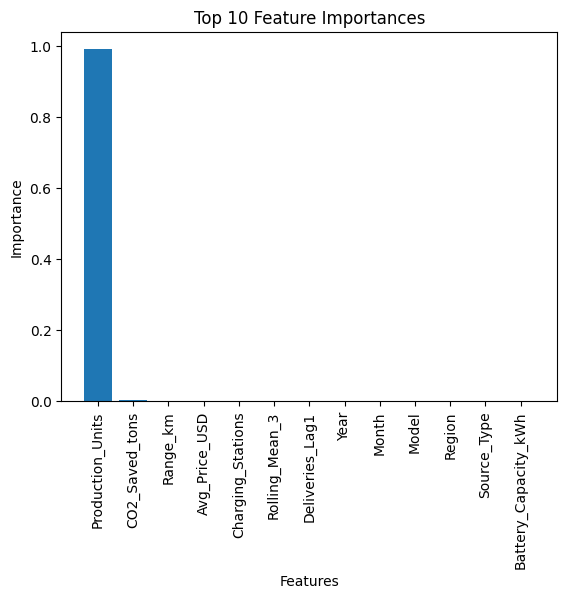

In [66]:
plt.figure()
plt.bar(final["Feature"], final["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)

plt.show()

# 8. ADF Stationarity Test

Ran an Augmented Dickey-Fuller test on Estimated_Deliveries to check if the series is stationary. The p-value came out to 0.0, which is well below 0.05, so I'm rejecting the null hypothesis — the series is stationary and doesn't need differencing.

In [67]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Estimated_Deliveries"])
print("P-value:", result[1])

if result[1] < 0.05:
    print("The data is stationary.")
else:
    print("The data is not stationary.")

P-value: 0.0
The data is stationary.


# 9. Forecast Table

Built a table comparing actual vs predicted deliveries for the first 20 test records, along with the error percentage for each. Most predictions are within 5-6% of the actual value, which seems reasonable.

In [68]:
forecast = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

forecast["Error"] = abs((forecast["Actual"] - forecast["Predicted"]) / forecast["Actual"]) * 100

forecast.head(20)

,Actual,Predicted,Error
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


# 10. Model Comparison

The Linear Regression and Random Forest models were compared using MAE, RMSE, and R² score. Both models performed well on this dataset, with R² scores above 0.99 for each.

In [69]:
linear_mae = mean_absolute_error(y_test, y_pred_lr)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
linear_r2 = r2_score(y_test, y_pred_lr)

random_mae = mean_absolute_error(y_test, y_pred_rf)
random_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
random_r2 = r2_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, random_mae],
    "RMSE": [linear_rmse, random_rmse],
    "R2": [linear_r2, random_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


# 11. Results

After analyzing the data and training both models, I found that both Linear Regression and Random Forest performed very well. The comparison table helped me understand which model made more accurate predictions. The feature importance chart also showed which features had the biggest impact on predicting deliveries.

# 12. Conclusion

In this assignment, I loaded the dataset, explored it using charts, created new features, trained machine learning models, and compared their performance. This helped me understand the complete machine learning workflow, from data preparation to model evaluation.